## SURVEY RESULTS & ANOVA Hypothesis Testing

Using the one-sided and 5% significance level table is in ANOVA, to test whether the F-statistic is significantly large.

In [1]:
!pip install -qqq statsmodels

In [2]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import csv
import os
print(os.getcwd())

/content


In [3]:
# Load the chatbot evaluation data from CSV
csv_file_path = './survey_result3.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

# Clean column names - remove trailing semicolons
df.columns = df.columns.str.replace(';;', '')

# Clean column names - remove trailing semicolons
df.columns = df.columns.str.replace(';;', '')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nChatbot types: {df['Chatbot_Type'].unique()}")
print(f"\nParticipants per chatbot type: {df.groupby('Chatbot_Type').size()}")

Dataset shape: (90, 6)

Chatbot types: ['Centralized_RAG' 'Federated_RAG' 'Retrieval_Based']

Participants per chatbot type: Chatbot_Type
Centralized_RAG    30
Federated_RAG      30
Retrieval_Based    30
dtype: int64


In [4]:
# Verify the data loaded correctly
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Total rows: 90
Columns: ['Participant', 'Chatbot_Type', 'Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']


In [5]:
# Display the first 15 rows to see data for all chatbot types
df.head(90)

,Participant,Chatbot_Type,Relevance,Coherence,Ambiguity_Handling,User_Satisfaction
0,1,Centralized_RAG,4,4,5,5
1,2,Centralized_RAG,7,6,7,6
2,3,Centralized_RAG,9,9,9,8
3,4,Centralized_RAG,8,8,8,8
4,5,Centralized_RAG,8,8,7,9
...,...,...,...,...,...,...
85,26,Retrieval_Based,6,6,7,6
86,27,Retrieval_Based,5,5,5,5
87,28,Retrieval_Based,7,7,6,6
88,29,Retrieval_Based,6,7,6,7


In [6]:
# Summary Statistics by Chatbot Type
print("Summary by Chatbot Type")
print()
metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']
chatbot_types = ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']

summary_data = []
for chatbot in chatbot_types:
    chatbot_df = df[df['Chatbot_Type'] == chatbot]
    print(f"\n{chatbot}:")
    print("-" * 80)

    for metric in metrics:
        mean_val = chatbot_df[metric].mean()
        std_val = chatbot_df[metric].std()
        min_val = chatbot_df[metric].min()
        max_val = chatbot_df[metric].max()
        median_val = chatbot_df[metric].median()

        print(f"  {metric:20s}: Mean={mean_val:5.2f}, Std={std_val:5.2f}, "
              f"Median={median_val:4.1f}, Range=[{min_val:2d}, {max_val:2d}]")

        summary_data.append({
            'Chatbot_Type': chatbot,
            'Metric': metric,
            'Mean': mean_val,
            'Std': std_val,
            'Median': median_val,
            'Min': min_val,
            'Max': max_val
        })

# Summary dataframe
summary_df = pd.DataFrame(summary_data)
print("Summary data saved ...")

Summary by Chatbot Type


Centralized_RAG:
--------------------------------------------------------------------------------
  Relevance           : Mean= 7.47, Std= 1.22, Median= 7.0, Range=[ 4, 10]
  Coherence           : Mean= 7.37, Std= 1.33, Median= 7.5, Range=[ 4, 10]
  Ambiguity_Handling  : Mean= 7.23, Std= 1.01, Median= 7.0, Range=[ 5, 10]
  User_Satisfaction   : Mean= 7.50, Std= 1.17, Median= 7.5, Range=[ 5, 10]

Federated_RAG:
--------------------------------------------------------------------------------
  Relevance           : Mean= 9.03, Std= 1.25, Median= 9.0, Range=[ 5, 10]
  Coherence           : Mean= 8.93, Std= 1.20, Median= 9.0, Range=[ 5, 10]
  Ambiguity_Handling  : Mean= 8.90, Std= 1.27, Median= 9.0, Range=[ 5, 10]
  User_Satisfaction   : Mean= 9.17, Std= 1.12, Median= 9.0, Range=[ 5, 10]

Retrieval_Based:
--------------------------------------------------------------------------------
  Relevance           : Mean= 6.27, Std= 1.66, Median= 6.0, Range=[ 2, 10]
  Coh

In [7]:
# Subtotal Statistics - Mean Scores by Chatbot Type
print("SUBTOTAL: MEAN SCORES BY CHATBOT TYPE AND METRIC")
print()

# Create pivot table
pivot_means = df.groupby('Chatbot_Type')[metrics].mean()
print(pivot_means.round(2))

print("SUBTOTAL: OVERALL MEAN BY METRIC (ALL CHATBOT TYPES)")
print()

overall_means = df[metrics].mean()
print(overall_means.round(2))

print("MEAN BY CHATBOT TYPES)")
print()

chatbot_overall = df.groupby('Chatbot_Type')[metrics].mean().mean(axis=1)
print(chatbot_overall.round(2).sort_values(ascending=False))

SUBTOTAL: MEAN SCORES BY CHATBOT TYPE AND METRIC

                 Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
Chatbot_Type                                                                
Centralized_RAG       7.47       7.37                7.23               7.50
Federated_RAG         9.03       8.93                8.90               9.17
Retrieval_Based       6.27       6.30                6.00               6.43
SUBTOTAL: OVERALL MEAN BY METRIC (ALL CHATBOT TYPES)

Relevance             7.59
Coherence             7.53
Ambiguity_Handling    7.38
User_Satisfaction     7.70
dtype: float64
MEAN BY CHATBOT TYPES)

Chatbot_Type
Federated_RAG      9.01
Centralized_RAG    7.39
Retrieval_Based    6.25
dtype: float64


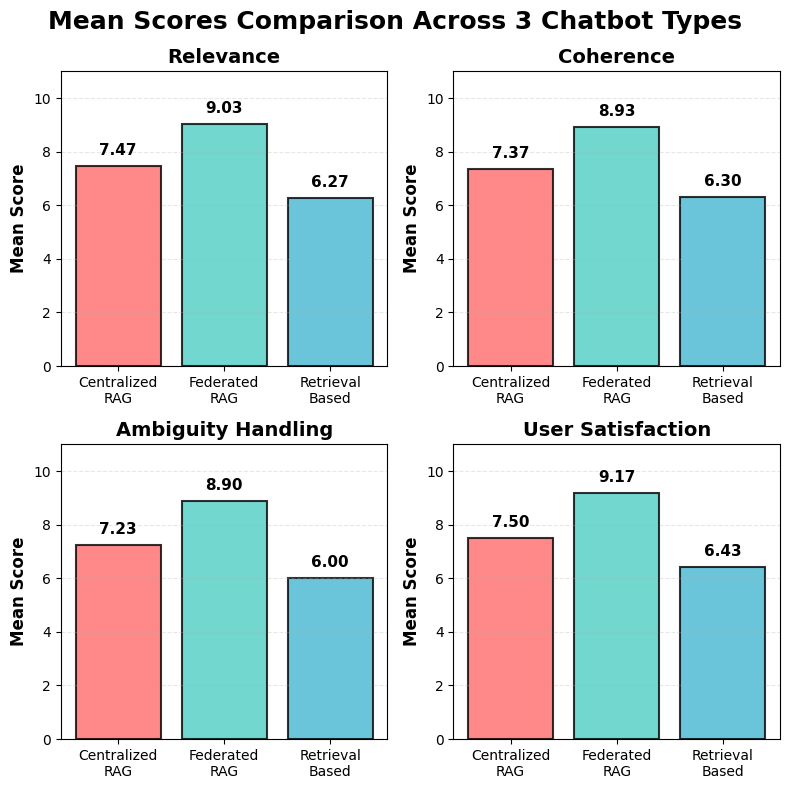

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Clean Visualization: Bar Chart Comparison of Mean Scores
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Mean Scores Comparison Across 3 Chatbot Types', fontsize=18, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    # Calculate means only
    means = df.groupby('Chatbot_Type')[metric].mean()

    x_pos = np.arange(len(means))
    bars = ax.bar(x_pos, means, color=colors, alpha=0.8,
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel('', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Score', fontsize=12, fontweight='bold')
    ax.set_title(metric.replace('_', ' '), fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Centralized\nRAG', 'Federated\nRAG', 'Retrieval\nBased'],
                       fontsize=10)
    ax.set_ylim(0, 11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


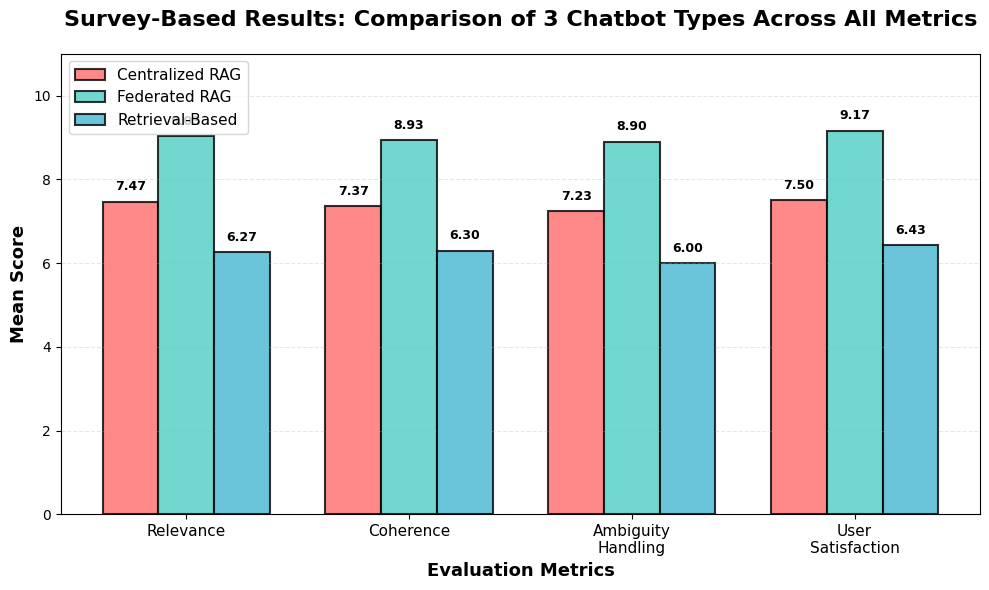

In [9]:
# Visualization 2: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.25

chatbot_types = ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['Centralized RAG', 'Federated RAG', 'Retrieval-Based']

for i, (chatbot, color, label) in enumerate(zip(chatbot_types, colors, labels)):
    means = [df[df['Chatbot_Type'] == chatbot][metric].mean() for metric in metrics]
    ax.bar(x + i*width, means, width, label=label, color=color,
           alpha=0.8, edgecolor='black', linewidth=1.5)

    # Add value labels
    for j, mean in enumerate(means):
        ax.text(x[j] + i*width, mean + 0.2, f'{mean:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score', fontsize=13, fontweight='bold')
ax.set_title('Survey-Based Results: Comparison of 3 Chatbot Types Across All Metrics',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('_', '\n') for m in metrics], fontsize=11)
ax.set_ylim(0, 11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


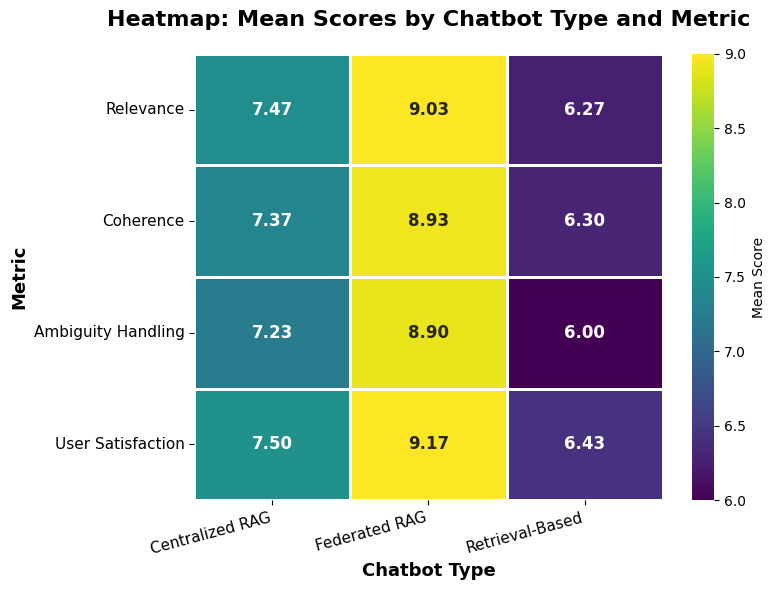

Heatmap visualization created


In [10]:
# Visualization: Heatmap of Mean Scores
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

pivot_data = df.groupby('Chatbot_Type')[metrics].mean()

sns.heatmap(pivot_data.T, annot=True, fmt='.2f', cmap='viridis',
            linewidths=2, cbar_kws={'label': 'Mean Score'}, ax=ax,
            vmin=6, vmax=9, annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Heatmap: Mean Scores by Chatbot Type and Metric',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Chatbot Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Metric', fontsize=13, fontweight='bold')
ax.set_yticklabels([m.replace('_', ' ') for m in metrics], rotation=0, fontsize=11)
ax.set_xticklabels(['Centralized RAG', 'Federated RAG', 'Retrieval-Based'],
                   rotation=15, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

print("Heatmap visualization created")

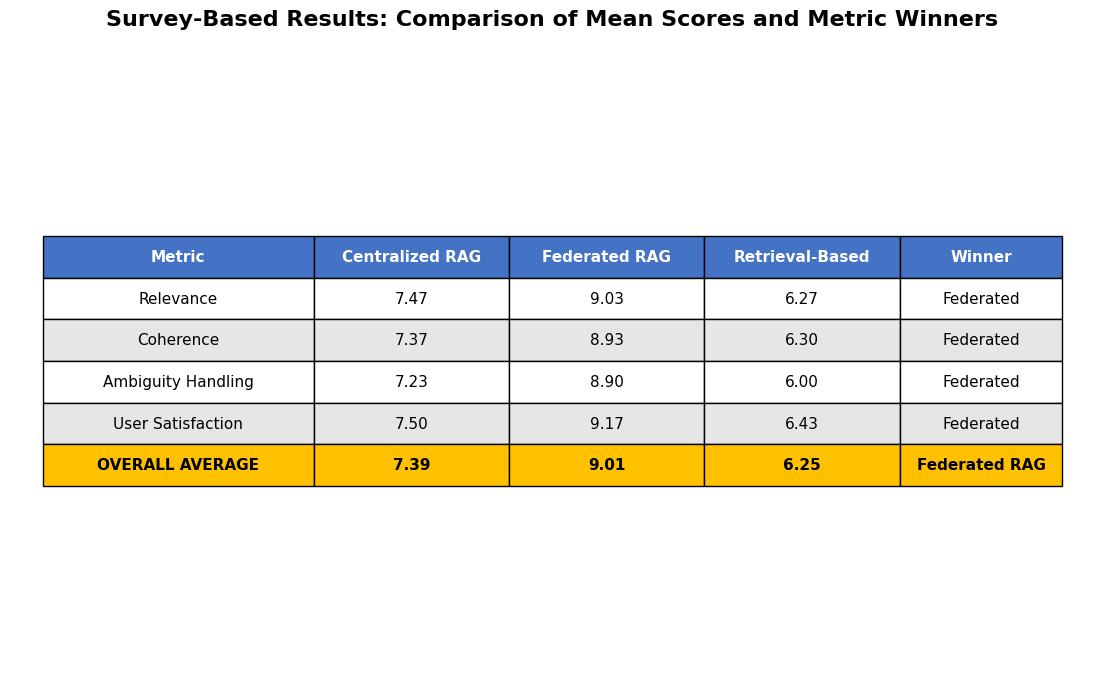

In [11]:
# Visualization: Summary Table with Rankings
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Create summary table data
table_data = []
table_data.append(['Metric', 'Centralized RAG', 'Federated RAG', 'Retrieval-Based', 'Winner'])

for metric in metrics:
    means = {ct: df[df['Chatbot_Type'] == ct][metric].mean() for ct in chatbot_types}
    winner = max(means, key=means.get)
    winner_label = {'Centralized_RAG': 'Centralized',
                    'Federated_RAG': 'Federated',
                    'Retrieval_Based': 'Retrieval'}[winner]

    row = [metric.replace('_', ' '),
           f"{means['Centralized_RAG']:.2f}",
           f"{means['Federated_RAG']:.2f}",
           f"{means['Retrieval_Based']:.2f}",
           winner_label]
    table_data.append(row)

# Add overall row
overall = [df[df['Chatbot_Type'] == ct][metrics].mean().mean() for ct in chatbot_types]
winner_idx = overall.index(max(overall))
winner_overall = ['Centralized', 'Federated RAG', 'Retrieval'][winner_idx]
table_data.append(['OVERALL AVERAGE',
                   f"{overall[0]:.2f}",
                   f"{overall[1]:.2f}",
                   f"{overall[2]:.2f}",
                   winner_overall])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                 colWidths=[0.25, 0.18, 0.18, 0.18, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style overall row
for i in range(5):
    table[(5, i)].set_facecolor('#FFC000')
    table[(5, i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, 5):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')

plt.title('Survey-Based Results: Comparison of Mean Scores and Metric Winners',
          fontsize=16, fontweight='bold', pad=20)
plt.show()

#### Null Hypothesis (H₀):
H₀ (Null Hypothesis): There is no significant difference in the coherence of responses generated by the RAG chatbot and the Retrieval-Based chatbot.

H₀ :μ RAG = μ Retrieval​

## EXAMPLE OF Manual Calculation of ANOVA

Now we will perform ANOVA analysis for each metric (Relevance, Coherence, Ambiguity_Handling, User_Satisfaction) across three chatbot types:
1. **Centralized_RAG**
2. **Federated_RAG**
3. **Retrieval_Based**

### Step-by-Step Calculation of ANOVA for Relevance:



## CODE Calculation of ANOVA


In [12]:
# Perform one-way ANOVA for Relevance
model_relevance = ols('Relevance ~ C(Chatbot_Type)', data=df).fit()
anova_relevance = sm.stats.anova_lm(model_relevance, typ=2)

print("ANOVA Results for Relevance")
print("="*60)
print(anova_relevance)
print("\n")

# Extract key statistics
f_stat = anova_relevance.loc['C(Chatbot_Type)', 'F']
p_value = anova_relevance.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Relevance")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Relevance")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Relevance
                     sum_sq    df          F        PR(>F)
C(Chatbot_Type)  115.488889   2.0  29.850069  1.346975e-10
Residual         168.300000  87.0        NaN           NaN


F-statistic: 29.8501
P-value: 0.000000

Conclusion: There is a statistically significant difference in Relevance
between the chatbot types (p < 0.05).
reject the null hypothesis


In [13]:
# One-way ANOVA for Coherence
model_coherence = ols('Coherence ~ C(Chatbot_Type)', data=df).fit()
anova_coherence = sm.stats.anova_lm(model_coherence, typ=2)

print("ANOVA Results for Coherence")
print("="*60)
print(anova_coherence)
print("\n")

# Extract key statistics
f_stat = anova_coherence.loc['C(Chatbot_Type)', 'F']
p_value = anova_coherence.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Coherence")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Coherence")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Coherence
                     sum_sq    df          F        PR(>F)
C(Chatbot_Type)  105.266667   2.0  29.902699  1.305598e-10
Residual         153.133333  87.0        NaN           NaN


F-statistic: 29.9027
P-value: 0.000000

Conclusion: There is a statistically significant difference in Coherence
between the chatbot types (p < 0.05).
reject the null hypothesis


In [14]:
# Perform one-way ANOVA for Ambiguity_Handling
model_ambiguity = ols('Ambiguity_Handling ~ C(Chatbot_Type)', data=df).fit()
anova_ambiguity = sm.stats.anova_lm(model_ambiguity, typ=2)

print("ANOVA Results for Ambiguity_Handling")
print("="*60)
print(anova_ambiguity)
print("\n")

# Extract key statistics
f_stat = anova_ambiguity.loc['C(Chatbot_Type)', 'F']
p_value = anova_ambiguity.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Ambiguity_Handling")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Ambiguity_Handling")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Ambiguity_Handling
                     sum_sq    df          F        PR(>F)
C(Chatbot_Type)  127.088889   2.0  33.695855  1.458627e-11
Residual         164.066667  87.0        NaN           NaN


F-statistic: 33.6959
P-value: 0.000000

Conclusion: There is a statistically significant difference in Ambiguity_Handling
between the chatbot types (p < 0.05).
reject the null hypothesis


In [15]:
# Perform one-way ANOVA for User_Satisfaction
model_satisfaction = ols('User_Satisfaction ~ C(Chatbot_Type)', data=df).fit()
anova_satisfaction = sm.stats.anova_lm(model_satisfaction, typ=2)

print("\n" + "="*60)
print("ANOVA Results for User_Satisfaction")
print("="*60)
print(anova_satisfaction)
print("\n")

# Extract key statistics
f_stat = anova_satisfaction.loc['C(Chatbot_Type)', 'F']
p_value = anova_satisfaction.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in User_Satisfaction")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in User_Satisfaction")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")


ANOVA Results for User_Satisfaction
                     sum_sq    df          F        PR(>F)
C(Chatbot_Type)  113.866667   2.0  35.120775  6.582778e-12
Residual         141.033333  87.0        NaN           NaN


F-statistic: 35.1208
P-value: 0.000000

Conclusion: There is a statistically significant difference in User_Satisfaction
between the chatbot types (p < 0.05).
reject the null hypothesis


#### Null Hypothesis (H₀) for Ambiguity Handling:
H₀ (Null Hypothesis): There is no significant difference between the RAG Chatbot and the Retrieval-Based Chatbot in handling ambiguous or incomplete queries. Both methods provide equally clear and contextually appropriate responses.

H₀ :μ RAG = μ Retrieval​

In [16]:
# Perform post-hoc Tukey HSD test for all metrics
from statsmodels.stats.multicomp import pairwise_tukeyhsd

metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

for metric in metrics:
    print("\n" + "="*70)
    print(f"Tukey HSD Post-hoc Test for {metric}")
    print("="*70)
    tukey = pairwise_tukeyhsd(endog=df[metric], groups=df['Chatbot_Type'], alpha=0.05)
    print(tukey)
    print("\n")


Tukey HSD Post-hoc Test for Relevance
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
Centralized_RAG   Federated_RAG   1.5667 0.0001  0.7104   2.423   True
Centralized_RAG Retrieval_Based     -1.2 0.0035 -2.0563 -0.3437   True
  Federated_RAG Retrieval_Based  -2.7667    0.0  -3.623 -1.9104   True
----------------------------------------------------------------------



Tukey HSD Post-hoc Test for Coherence
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------
Centralized_RAG   Federated_RAG   1.5667   0.0  0.7499  2.3835   True
Centralized_RAG Retrieval_Based  -1.0667 0.007 -1.8835 -0.2499   True
  Federated_RAG Retrieval_Based  -2.6333   0.0 -3.4501 -1.8165   True
---

## Complete ANOVA Analysis for All Metrics

This section presents a comprehensive One-Way ANOVA analysis for all four evaluation metrics:
- Relevance
- Coherence
- Ambiguity Handling
- User Satisfaction

**Hypothesis Testing:**
- **H₀ (Null Hypothesis)**: There is no difference in metric scores among the three chatbot types (μ₁ = μ₂ = μ₃)
- **H₁ (Alternative Hypothesis)**: At least one chatbot type has a different metric score
- **Significance Level**: α = 0.05

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [19]:
# Define the data based on survey results
# Centralized RAG
centralized_relevance = [4, 7, 9, 8, 8, 10, 10, 5, 9, 7, 7, 8, 7, 8, 7, 7, 8, 8, 7, 7, 7, 8, 8, 7, 7, 8, 6, 8, 7, 7]
centralized_coherence = [4, 6, 9, 8, 8, 10, 10, 5, 9, 7, 7, 8, 8, 8, 6, 6, 7, 8, 7, 7, 7, 8, 8, 7, 7, 8, 6, 8, 8, 6]
centralized_ambiguity = [5, 7, 9, 8, 7, 10, 7, 5, 8, 7, 7, 8, 7, 7, 7, 6, 7, 8, 7, 7, 7, 8, 8, 7, 7, 8, 6, 8, 7, 7]
centralized_satisfaction = [5, 6, 8, 8, 9, 10, 10, 5, 9, 7, 7, 8, 8, 7, 8, 7, 7, 8, 7, 7, 7, 8, 8, 7, 7, 8, 6, 8, 8, 7]

# Federated RAG
federated_relevance = [8, 7, 10, 9, 9, 10, 6, 5, 9, 10, 10, 9, 10, 10, 9, 10, 10, 10, 10, 10, 9, 10, 9, 8, 9, 10, 8, 9, 9, 9]
federated_coherence = [8, 8, 8, 9, 9, 10, 6, 5, 9, 10, 10, 9, 9, 10, 9, 10, 10, 10, 10, 10, 9, 10, 9, 8, 9, 9, 8, 9, 10, 8]
federated_ambiguity = [5, 8, 9, 9, 8, 10, 10, 5, 9, 10, 10, 9, 9, 9, 10, 9, 10, 10, 9, 10, 9, 10, 9, 8, 9, 10, 8, 9, 9, 8]
federated_satisfaction = [9, 7, 9, 9, 9, 10, 8, 5, 10, 10, 10, 9, 10, 10, 10, 10, 10, 10, 10, 10, 9, 10, 9, 8, 9, 9, 8, 9, 10, 9]

# Retrieval-Based
retrieval_relevance = [7, 7, 9, 6, 9, 10, 2, 5, 8, 9, 6, 6, 7, 7, 6, 5, 5, 5, 5, 4, 6, 7, 6, 5, 5, 6, 5, 7, 6, 7]
retrieval_coherence = [7, 6, 8, 6, 9, 10, 8, 5, 7, 9, 6, 6, 6, 6, 6, 4, 5, 5, 4, 4, 6, 7, 6, 6, 6, 6, 5, 7, 7, 6]
retrieval_ambiguity = [5, 8, 9, 6, 7, 10, 1, 5, 7, 9, 6, 6, 6, 7, 7, 4, 5, 5, 4, 4, 6, 7, 6, 5, 5, 7, 5, 6, 6, 6]
retrieval_satisfaction = [8, 7, 9, 6, 9, 10, 5, 5, 8, 9, 6, 6, 7, 6, 7, 5, 5, 5, 4, 4, 6, 7, 6, 6, 6, 6, 5, 6, 7, 7]


# Create structured DataFrame
data = []
for i in range(20):
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Centralized_RAG',
        'Relevance': centralized_relevance[i],
        'Coherence': centralized_coherence[i],
        'Ambiguity_Handling': centralized_ambiguity[i],
        'User_Satisfaction': centralized_satisfaction[i]
    })
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Federated_RAG',
        'Relevance': federated_relevance[i],
        'Coherence': federated_coherence[i],
        'Ambiguity_Handling': federated_ambiguity[i],
        'User_Satisfaction': federated_satisfaction[i]
    })
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Retrieval_Based',
        'Relevance': retrieval_relevance[i],
        'Coherence': retrieval_coherence[i],
        'Ambiguity_Handling': retrieval_ambiguity[i],
        'User_Satisfaction': retrieval_satisfaction[i]
    })

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 10 rows:")
df.head(90)

Dataset shape: (60, 6)

First 10 rows:


,Participant,Chatbot_Type,Relevance,Coherence,Ambiguity_Handling,User_Satisfaction
0,1,Centralized_RAG,4,4,5,5
1,1,Federated_RAG,8,8,5,9
2,1,Retrieval_Based,7,7,5,8
3,2,Centralized_RAG,7,6,7,6
4,2,Federated_RAG,7,8,8,7
5,2,Retrieval_Based,7,6,8,7
6,3,Centralized_RAG,9,9,9,8
7,3,Federated_RAG,10,8,9,9
8,3,Retrieval_Based,9,8,9,9
9,4,Centralized_RAG,8,8,8,8


In [20]:
# Display descriptive statistics by chatbot type
print("Descriptive Statistics by Chatbot Type\n" + "="*80)
for chatbot in ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']:
    print(f"\n{chatbot}:")
    subset = df[df['Chatbot_Type'] == chatbot]
    print(subset[['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']].describe())

Descriptive Statistics by Chatbot Type

Centralized_RAG:
       Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
count  20.000000  20.000000           20.000000          20.000000
mean    7.550000   7.400000            7.200000           7.550000
std     1.431782   1.535544            1.151658           1.356272
min     4.000000   4.000000            5.000000           5.000000
25%     7.000000   6.750000            7.000000           7.000000
50%     7.500000   7.500000            7.000000           7.500000
75%     8.000000   8.000000            8.000000           8.000000
max    10.000000  10.000000           10.000000          10.000000

Federated_RAG:
       Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
count  20.000000  20.000000            20.00000          20.000000
mean    9.050000   8.950000             8.90000           9.250000
std     1.468081   1.394538             1.48324           1.292692
min     5.000000   5.000000             5.00000         

### ANOVA Analysis Function

In [21]:
def perform_anova(df, metric_name):
    """
    Perform One-Way ANOVA for a given metric

    Parameters:
    - df: DataFrame containing the data
    - metric_name: Name of the metric column to analyze

    Returns:
    - Dictionary containing ANOVA results
    """
    # Extract data for each chatbot type
    centralized = df[df['Chatbot_Type'] == 'Centralized_RAG'][metric_name].values
    federated = df[df['Chatbot_Type'] == 'Federated_RAG'][metric_name].values
    retrieval = df[df['Chatbot_Type'] == 'Retrieval_Based'][metric_name].values

    # Calculate group means
    mean_centralized = np.mean(centralized)
    mean_federated = np.mean(federated)
    mean_retrieval = np.mean(retrieval)
    grand_mean = np.mean(np.concatenate([centralized, federated, retrieval]))  # Weighted grand mean

    # Calculate SSB (Sum of Squares Between Groups)
    n = len(centralized)  # sample size per group (dynamically calculated)
    SSB = n * ((mean_centralized - grand_mean)**2 +
               (mean_federated - grand_mean)**2 +
               (mean_retrieval - grand_mean)**2)

    # Calculate SSW (Sum of Squares Within Groups)
    ssw_centralized = np.sum((centralized - mean_centralized)**2)
    ssw_federated = np.sum((federated - mean_federated)**2)
    ssw_retrieval = np.sum((retrieval - mean_retrieval)**2)
    SSW = ssw_centralized + ssw_federated + ssw_retrieval

    # Degrees of Freedom
    k = 3  # number of groups
    N = len(centralized) + len(federated) + len(retrieval)  # total sample size (dynamically calculated)
    dfB = k - 1
    dfW = N - k

    # Mean Squares
    MSB = SSB / dfB
    MSW = SSW / dfW

    # F-statistic
    F_statistic = MSB / MSW
    F_critical = stats.f.ppf(0.95, dfB, dfW)
    p_value = 1 - stats.f.cdf(F_statistic, dfB, dfW)

    # Decision
    decision = "Reject H₀" if F_statistic > F_critical else "Fail to Reject H₀"
    conclusion = "Significant difference exists" if F_statistic > F_critical else "No significant difference"

    return {
        'Metric': metric_name.replace('_', ' '),
        'Mean_Centralized': mean_centralized,
        'Mean_Federated': mean_federated,
        'Mean_Retrieval': mean_retrieval,
        'Grand_Mean': grand_mean,
        'SSB': SSB,
        'SSW': SSW,
        'dfB': dfB,
        'dfW': dfW,
        'MSB': MSB,
        'MSW': MSW,
        'F_Statistic': F_statistic,
        'F_Critical': F_critical,
        'P_Value': p_value,
        'Decision': decision,
        'Conclusion': conclusion
    }

### Perform ANOVA for All Metrics

In [22]:
# Metrics to analyze
metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

# Perform ANOVA for each metric
results = []
for metric in metrics:
    result = perform_anova(df, metric)
    results.append(result)

    print(f"\n{'='*100}")
    print(f"ANOVA Results for {result['Metric'].upper()}")
    print(f"{'='*100}")
    print(f"\nGroup Means:")
    print(f"  Centralized RAG: {result['Mean_Centralized']:.4f}")
    print(f"  Federated RAG: {result['Mean_Federated']:.4f}")
    print(f"  Retrieval-Based: {result['Mean_Retrieval']:.4f}")
    print(f"  Grand Mean: {result['Grand_Mean']:.4f}")
    print(f"\nANOVA Table:")
    print(f"  SSB (Between Groups): {result['SSB']:.4f}")
    print(f"  SSW (Within Groups): {result['SSW']:.4f}")
    print(f"  MSB: {result['MSB']:.4f}")
    print(f"  MSW: {result['MSW']:.4f}")
    print(f"\nHypothesis Test:")
    print(f"  F-Statistic: {result['F_Statistic']:.4f}")
    print(f"  F-Critical (α=0.05): {result['F_Critical']:.4f}")
    print(f"  P-Value: {result['P_Value']:.6f}")
    print(f"  Decision: {result['Decision']}")
    print(f"  Conclusion: {result['Conclusion']}")


ANOVA Results for RELEVANCE

Group Means:
  Centralized RAG: 7.5500
  Federated RAG: 9.0500
  Retrieval-Based: 6.4000
  Grand Mean: 7.6667

ANOVA Table:
  SSB (Between Groups): 70.6333
  SSW (Within Groups): 152.7000
  MSB: 35.3167
  MSW: 2.6789

Hypothesis Test:
  F-Statistic: 13.1830
  F-Critical (α=0.05): 3.1588
  P-Value: 0.000020
  Decision: Reject H₀
  Conclusion: Significant difference exists

ANOVA Results for COHERENCE

Group Means:
  Centralized RAG: 7.4000
  Federated RAG: 8.9500
  Retrieval-Based: 6.3500
  Grand Mean: 7.5667

ANOVA Table:
  SSB (Between Groups): 68.4333
  SSW (Within Groups): 138.3000
  MSB: 34.2167
  MSW: 2.4263

Hypothesis Test:
  F-Statistic: 14.1023
  F-Critical (α=0.05): 3.1588
  P-Value: 0.000011
  Decision: Reject H₀
  Conclusion: Significant difference exists

ANOVA Results for AMBIGUITY HANDLING

Group Means:
  Centralized RAG: 7.2000
  Federated RAG: 8.9000
  Retrieval-Based: 6.0500
  Grand Mean: 7.3833

ANOVA Table:
  SSB (Between Groups): 82.23

### Summary Table - All Metrics

In [23]:
# Create summary DataFrame
summary_df = pd.DataFrame(results)

# Display summary table
print("\n" + "="*100)
print("SUMMARY TABLE - ANOVA RESULTS FOR ALL METRICS")
print("="*100)
print()

summary_table = summary_df[['Metric', 'F_Statistic', 'F_Critical', 'P_Value', 'Decision', 'Conclusion']]
print(summary_table.to_string(index=False))

# Display as formatted table
summary_table


SUMMARY TABLE - ANOVA RESULTS FOR ALL METRICS

            Metric  F_Statistic  F_Critical  P_Value  Decision                    Conclusion
         Relevance    13.183039    3.158843 0.000020 Reject H₀ Significant difference exists
         Coherence    14.102314    3.158843 0.000011 Reject H₀ Significant difference exists
Ambiguity Handling    15.629543    3.158843 0.000004 Reject H₀ Significant difference exists
 User Satisfaction    16.640815    3.158843 0.000002 Reject H₀ Significant difference exists


,Metric,F_Statistic,F_Critical,P_Value,Decision,Conclusion
0,Relevance,13.183039,3.158843,0.000020,Reject H₀,Significant difference exists
1,Coherence,14.102314,3.158843,0.000011,Reject H₀,Significant difference exists
2,Ambiguity Handling,15.629543,3.158843,0.000004,Reject H₀,Significant difference exists
3,User Satisfaction,16.640815,3.158843,0.000002,Reject H₀,Significant difference exists


### Group Means Comparison Table

In [24]:
# Create means comparison table
means_comparison = summary_df[['Metric', 'Mean_Centralized', 'Mean_Federated', 'Mean_Retrieval', 'Grand_Mean']]
means_comparison.columns = ['Metric', 'Centralized RAG', 'Federated RAG', 'Retrieval-Based', 'Grand Mean']

print("\nGroup Means Comparison")
print("="*100)
print(means_comparison.to_string(index=False))
print()

means_comparison


Group Means Comparison
            Metric  Centralized RAG  Federated RAG  Retrieval-Based  Grand Mean
         Relevance             7.55           9.05             6.40    7.666667
         Coherence             7.40           8.95             6.35    7.566667
Ambiguity Handling             7.20           8.90             6.05    7.383333
 User Satisfaction             7.55           9.25             6.55    7.783333



,Metric,Centralized RAG,Federated RAG,Retrieval-Based,Grand Mean
0,Relevance,7.55,9.05,6.40,7.666667
1,Coherence,7.40,8.95,6.35,7.566667
2,Ambiguity Handling,7.20,8.90,6.05,7.383333
3,User Satisfaction,7.55,9.25,6.55,7.783333


### Visualization - Group Means by Metric

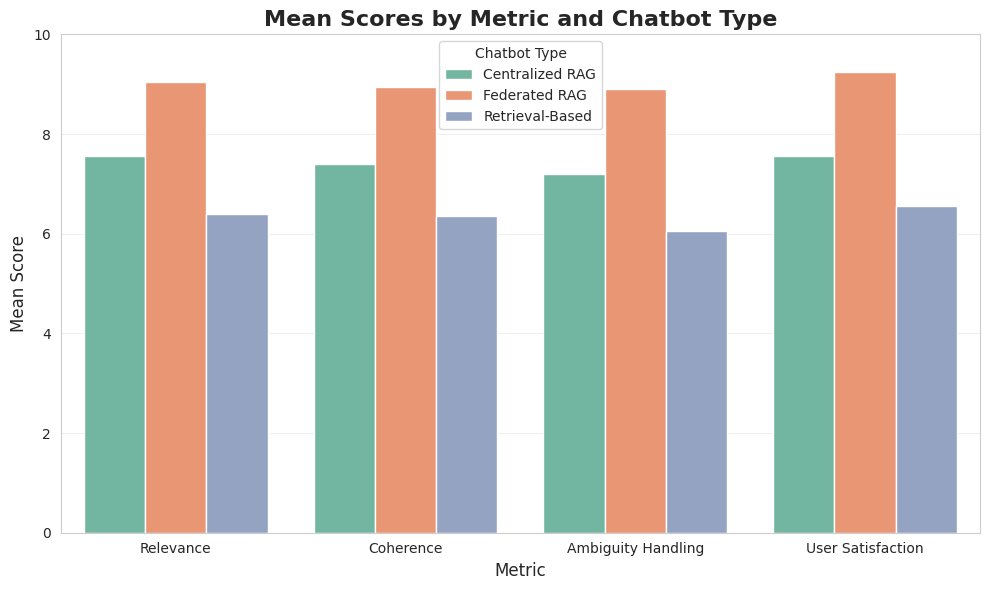

In [25]:
# Prepare data for visualization
plot_data = []
for _, row in summary_df.iterrows():
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Centralized RAG', 'Mean Score': row['Mean_Centralized']})
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Federated RAG', 'Mean Score': row['Mean_Federated']})
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Retrieval-Based', 'Mean Score': row['Mean_Retrieval']})

plot_df = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x='Metric', y='Mean Score', hue='Chatbot Type', palette='Set2', ax=ax)
ax.set_title('Mean Scores by Metric and Chatbot Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.legend(title='Chatbot Type', fontsize=10)
ax.set_ylim(0, 10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization - F-Statistics Comparison

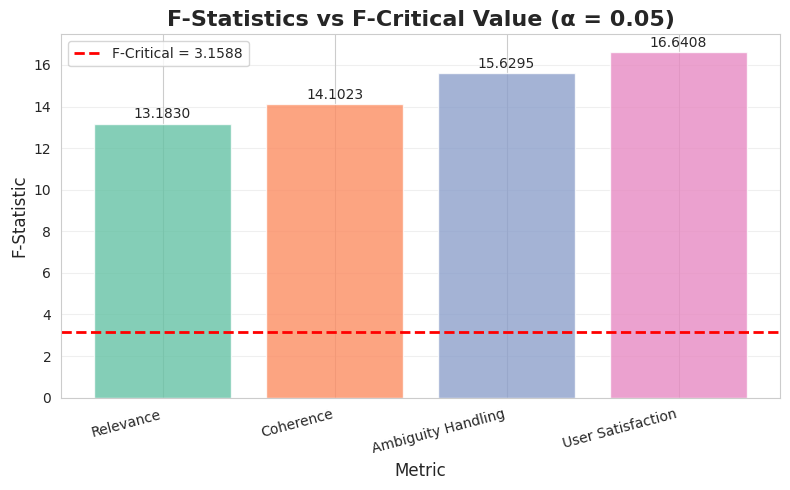


Note: All F-statistics are above the F-critical value, indicating significant differences.


In [26]:
# Create F-statistic comparison plot
fig, ax = plt.subplots(figsize=(8, 5))

metrics_list = summary_df['Metric'].tolist()
f_stats = summary_df['F_Statistic'].tolist()
f_critical = summary_df['F_Critical'].iloc[0]  # Same for all

x_pos = np.arange(len(metrics_list))
bars = ax.bar(x_pos, f_stats, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'], alpha=0.8)
ax.axhline(y=f_critical, color='red', linestyle='--', linewidth=2, label=f'F-Critical = {f_critical:.4f}')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('F-Statistic', fontsize=12)
ax.set_title('F-Statistics vs F-Critical Value (α = 0.05)', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_list, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, f_stats)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nNote: All F-statistics are above the F-critical value, indicating significant differences.")

In [27]:
# Save results to CSV
summary_df.to_csv('anova_summary_results.csv', index=False)
print("Results saved to 'anova_summary_results.csv'")

Results saved to 'anova_summary_results.csv'
